In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
DIR = "/data/user_data/sheels/Spring2026/10718_mlip/"

In [3]:
reviews = f"{DIR}/data/goodreads_reviews_dedup.json"
df = pd.read_json(reviews, lines=True)

In [4]:
df.head()

,user_id,book_id,review_id,rating,review_text,date_added,date_updated,read_at,started_at,n_votes,n_comments
0,8842281e1d1347389f2ab93d60773d4d,24375664,5cd416f3efc3f944fce4ce2db2290d5e,5,Mind blowingly cool. Best science fiction I've...,Fri Aug 25 13:55:02 -0700 2017,Mon Oct 09 08:55:59 -0700 2017,Sat Oct 07 00:00:00 -0700 2017,Sat Aug 26 00:00:00 -0700 2017,16,0
1,8842281e1d1347389f2ab93d60773d4d,18245960,dfdbb7b0eb5a7e4c26d59a937e2e5feb,5,This is a special book. It started slow for ab...,Sun Jul 30 07:44:10 -0700 2017,Wed Aug 30 00:00:26 -0700 2017,Sat Aug 26 12:05:52 -0700 2017,Tue Aug 15 13:23:18 -0700 2017,28,1
2,8842281e1d1347389f2ab93d60773d4d,6392944,5e212a62bced17b4dbe41150e5bb9037,3,I haven't read a fun mystery book in a while a...,Mon Jul 24 02:48:17 -0700 2017,Sun Jul 30 09:28:03 -0700 2017,Tue Jul 25 00:00:00 -0700 2017,Mon Jul 24 00:00:00 -0700 2017,6,0
3,8842281e1d1347389f2ab93d60773d4d,22078596,fdd13cad0695656be99828cd75d6eb73,4,"Fun, fast paced, and disturbing tale of murder...",Mon Jul 24 02:33:09 -0700 2017,Sun Jul 30 10:23:54 -0700 2017,Sun Jul 30 15:42:05 -0700 2017,Tue Jul 25 00:00:00 -0700 2017,22,4
4,8842281e1d1347389f2ab93d60773d4d,6644782,bd0df91c9d918c0e433b9ab3a9a5c451,4,A fun book that gives you a sense of living in...,Mon Jul 24 02:28:14 -0700 2017,Thu Aug 24 00:07:20 -0700 2017,Sat Aug 05 00:00:00 -0700 2017,Sun Jul 30 00:00:00 -0700 2017,8,0


In [5]:
user_counts = df.user_id.value_counts().reset_index()
good_users = user_counts[user_counts['count'] > 10]['user_id']
print(good_users.shape)


(181013,)


In [6]:
book_counts = df.book_id.value_counts().reset_index()
good_books = book_counts[book_counts['count'] > 100]['book_id']
print(good_books.shape)

(18443,)


In [7]:
good_reviews = df[(df['user_id'].isin(good_users)) & (df['book_id'].isin(good_books))]
print(good_reviews.shape)

(5920702, 11)


In [8]:
good_reviews.to_csv(f"{DIR}/data/good_reviews.csv", index=False)

In [11]:
rating_counts = good_reviews.rating.value_counts().reset_index()
print(rating_counts)

   rating    count
0       5  2064930
1       4  1979212
2       3  1132307
3       2   409108
4       1   169590
5       0   165555


In [25]:
plt.rcParams.update({
    "font.family": "serif",  # NeurIPS uses Roman fonts
    "font.serif": ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",  # Use Computer Modern for math
    "text.usetex": False,     # Requires a working LaTeX installation
    "pgf.rcfonts": False,
    "font.size": 10,         # Standard size for captions/labels
    "axes.labelsize": 10,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "lines.linewidth": 1.5,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
})
colors = {
    "royal_blue": "#004488",
    "goldenrod":  "#DDAA33",
    "raspberry":  "#BB5566",
    "teal":       "#44AA99",
    "charcoal":   "#333333",
    "deep_purple": "#663399",  # Great for "Baselines" or "Ground Truth"
    "sage_green":  "#889944",  # A more organic, professional green than standard 'lime'
    "burnt_orange": "#EE8866", # Softer than pure orange, pairs well with royal_blue
    "sky_blue":     "#77AADD", # Good for shaded regions or secondary lines
    "wine_red":     "#994455", # A darker, serious alternative to raspberry
    "slate_grey":   "#999999"  # Perfect for "Other Methods" or background noise
}

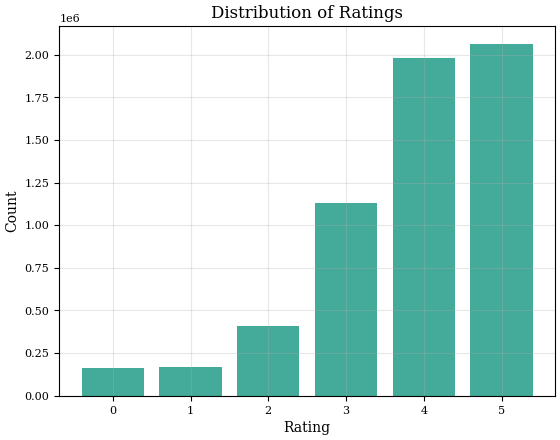

In [19]:
plt.bar(rating_counts['rating'], rating_counts['count'], color=colors['teal'])
plt.xlabel('Rating')
plt.ylabel('Count')
plt.title('Distribution of Ratings')
plt.savefig('rating_distribution.png')
plt.show()

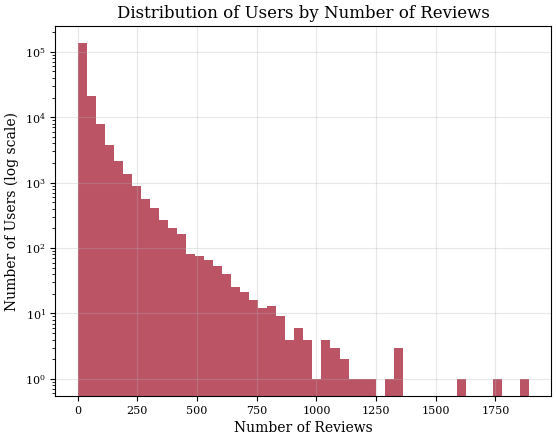

In [24]:
user_counts = good_reviews.user_id.value_counts().reset_index()
plt.hist(user_counts['count'], bins=50, color=colors['raspberry'])
plt.yscale('log')
plt.xlabel('Number of Reviews')
plt.ylabel('Number of Users (log scale)')
plt.title('Distribution of Users by Number of Reviews')
plt.savefig('user_review_distribution.png')
plt.show()

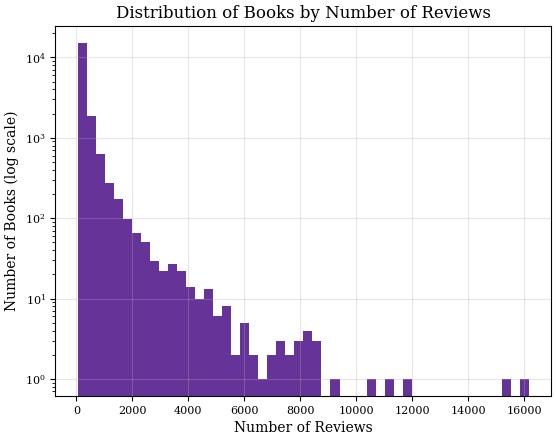

In [27]:
book_counts = good_reviews.book_id.value_counts().reset_index()
plt.hist(book_counts['count'], bins=50, color=colors['deep_purple'])
plt.yscale('log')
plt.xlabel('Number of Reviews')
plt.ylabel('Number of Books (log scale)')
plt.title('Distribution of Books by Number of Reviews')
plt.savefig('book_review_distribution.png')
plt.show()

In [32]:
good_reviews.read_at = pd.to_datetime(good_reviews.read_at, format='%a %b %d %H:%M:%S %z %Y', utc=True)
good_reviews.started_at = pd.to_datetime(good_reviews.started_at, format='%a %b %d %H:%M:%S %z %Y', utc=True)
time_for_reading = good_reviews.read_at.dt.date - good_reviews.started_at.dt.date
print(time_for_reading.describe())

count            3540474
unique              2304
top       1 day, 0:00:00
freq              528778
dtype: object


In [42]:
time_for_reading = good_reviews.read_at - good_reviews.started_at
time_for_reading.describe()

count                     3540474
mean      16 days 17:15:19.700729
std      974 days 15:49:13.304498
min        -198326 days +22:07:10
25%               1 days 10:46:38
50%               4 days 00:00:00
75%               9 days 23:15:53
max          736178 days 00:00:00
dtype: object

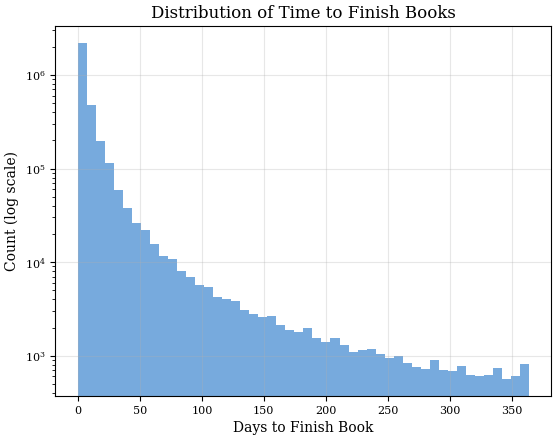

In [45]:
time_for_reading = time_for_reading[(time_for_reading > pd.Timedelta(0)) & (time_for_reading < pd.Timedelta(days=365))]
plt.hist(time_for_reading.dt.days, bins=50, color=colors['sky_blue'])
plt.xlabel('Days to Finish Book')
plt.ylabel('Count (log scale)')
plt.yscale('log')

plt.title('Distribution of Time to Finish Books')
plt.savefig('time_to_finish_books.png')
plt.show()

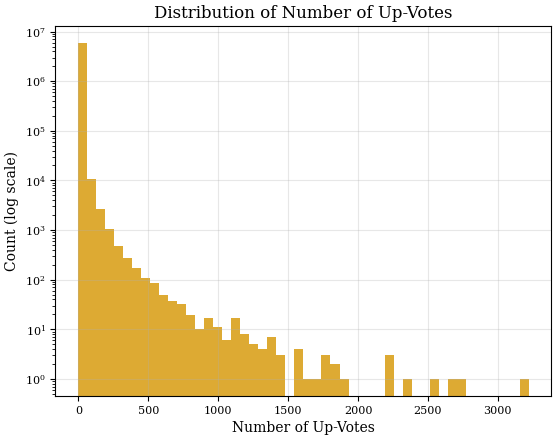

In [48]:
# good_reviews.nvotes
plt.hist(good_reviews.n_votes, bins=50, color=colors['goldenrod'])
plt.xlabel('Number of Up-Votes')
plt.ylabel('Count (log scale)')
plt.yscale('log')
plt.title('Distribution of Number of Up-Votes')
plt.savefig('number_of_up_votes.png')
plt.show()

In [3]:
df = pd.read_csv(f"{DIR}/data/good_reviews.csv")

In [4]:
df.head()

,user_id,book_id,review_id,rating,review_text,date_added,date_updated,read_at,started_at,n_votes,n_comments
0,8842281e1d1347389f2ab93d60773d4d,16981,a5d2c3628987712d0e05c4f90798eb67,3,Recommended by Don Katz. Avail for free in Dec...,Mon Dec 05 10:46:44 -0800 2016,Wed Mar 22 11:37:04 -0700 2017,NaN,NaN,1,0
1,8842281e1d1347389f2ab93d60773d4d,28684704,2ede853b14dc4583f96cf5d120af636f,3,"A fun, fast paced science fiction thriller. I ...",Tue Nov 15 11:29:22 -0800 2016,Mon Mar 20 23:40:27 -0700 2017,Sat Mar 18 23:22:42 -0700 2017,Fri Mar 17 23:45:40 -0700 2017,22,0
2,8842281e1d1347389f2ab93d60773d4d,27161156,ced5675e55cd9d38a524743f5c40996e,0,Recommended reading to understand what is goin...,Wed Nov 09 17:37:04 -0800 2016,Wed Nov 09 17:38:20 -0800 2016,NaN,NaN,5,1
3,8842281e1d1347389f2ab93d60773d4d,32283133,8e4d61801907e591018bdc3442a9cf2b,0,http://www.telegraph.co.uk/culture/10...,Tue Nov 01 11:09:18 -0700 2016,Tue Nov 01 11:09:44 -0700 2016,NaN,NaN,9,0
4,8842281e1d1347389f2ab93d60773d4d,28119237,7a8dc8ab7f3c0084be8150d7e5bd40cb,4,A fascinating book about community and belongi...,Thu Sep 22 16:19:12 -0700 2016,Thu Sep 22 16:19:12 -0700 2016,Tue Nov 22 00:00:00 -0800 2016,NaN,30,2


In [5]:
df.rating.value_counts()

rating
5    2064930
4    1979212
3    1132307
2     409108
1     169590
0     165555
Name: count, dtype: int64

In [6]:
# for each rating, select a random subset of 165555 entries
sub_dfs = []
ratings = [0, 1, 2, 3, 4, 5]
for rating in ratings:
    sub_dfs.append(df.loc[df['rating'] == rating].sample(n=165555, random_state=42))

In [7]:
sub_df = pd.concat(sub_dfs)

In [8]:
sub_df.shape

(993330, 11)

In [9]:
sub_df.head()

,user_id,book_id,review_id,rating,review_text,date_added,date_updated,read_at,started_at,n_votes,n_comments
166248,527495740745b66955aa393d4598f937,31574739,37db46420826fde4b4fd7d433dfe73d5,0,a very well written and thoughtful horror stor...,Fri Aug 18 18:20:27 -0700 2017,Thu Aug 24 09:39:56 -0700 2017,Thu Aug 24 14:02:51 -0700 2017,Fri Aug 18 00:00:00 -0700 2017,8,1
3007700,46f4b1de8eefb4f72c05cea2955a172b,2767793,97b886f98ff8b6a06a7b2ebeaa400e98,0,Lexile HL750L \n IL: UG - BL: 5.7 - AR Pts: 37.0,Thu Nov 18 07:43:26 -0800 2010,Fri May 13 19:16:04 -0700 2016,NaN,NaN,0,0
1530334,aa61a59d0e815475001dee78ee57956a,7735333,62582d01f8b23c4219ac61c29f039086,0,this is like the glitch novels.... I felt like...,Thu Oct 08 19:05:17 -0700 2015,Sat Jan 23 11:37:42 -0800 2016,Sat Jan 23 11:37:42 -0800 2016,Wed Jan 20 00:00:00 -0800 2016,0,0
2517867,434424a3e0e44eadb921c5b6dd13fb55,830,61f47cdde36989b38436de92f28c349c,0,"This is more like ""light reading"" than other S...",Wed Jan 23 16:16:09 -0800 2013,Sun Feb 17 15:52:24 -0800 2013,Sun Feb 17 15:52:24 -0800 2013,Wed Jan 23 00:00:00 -0800 2013,0,0
1688850,acf14700423134c5bd30451689e8c180,70401,f7f695f5efaf002a300e18c38463de06,0,Por si alguien no lo sabe: Navokov se inspiro ...,Thu Mar 12 19:57:35 -0700 2009,Thu Mar 12 19:58:29 -0700 2009,NaN,NaN,0,0


In [10]:
sub_df.to_csv(f"{DIR}/data/subsampled_good_reviews.csv", index=False)

In [11]:
df = pd.read_csv(f"{DIR}/data/goodreads_interactions.csv")

In [12]:
df.head()

,user_id,book_id,is_read,rating,is_reviewed
0,0,948,1,5,0
1,0,947,1,5,1
2,0,946,1,5,0
3,0,945,1,5,0
4,0,944,1,5,0


In [13]:
df.is_read.mean()

np.float64(0.49040899233811197)

In [14]:
sub_df.shape

(993330, 11)

In [16]:
sub_df.user_id.value_counts().shape

(144506,)